## Libraries

In [2]:
!pip install lime shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=61a10daab38559465a122f4488c79bedb710913cedf5713339b758a06ca951f7
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, f1_score, confusion_matrix, precision_recall_curve, accuracy_score, average_precision_score, precision_score, recall_score
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import GridSearchCV
import lime
import lime.lime_tabular
import shap
from sklearn.metrics import ConfusionMatrixDisplay

## Loading files....

In [6]:
df = pd.read_excel("/content/synthetic_machine_failure (1).xlsx")

## dropping unused columns...

In [7]:
df_model = df.drop(columns=["Machine_ID", "Timestamp"])

## features and target....

In [8]:
X = df_model.drop(columns=["Failure"])
y = df_model["Failure"]

## scale features...

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## train-test split....

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

## applying SMOTE...

In [ ]:
# sm = SMOTE(random_state=42)
# X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

In [11]:
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train, y_train)

## Loss function...

In [ ]:
# def focal_loss(gamma=2., alpha=0.25):
  #  def focal_loss_fixed(y_true, y_pred):
   #     pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
    #    return -K.mean(alpha * K.pow(1. - pt, gamma) * K.log(pt + K.epsilon()))
   # return focal_loss_fixed

In [12]:
def focal_loss(gamma=2., alpha=0.75):
    def focal_loss_fixed(y_true, y_pred):
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        return -K.mean(alpha * K.pow(1. - pt, gamma) * K.log(pt + K.epsilon()))
    return focal_loss_fixed

## handling class imbalance...

In [ ]:
# weights = class_weight.compute_class_weight(
#    class_weight='balanced',
#    classes=np.unique(y_train),
#    y=y_train
# )
#class_weights_dict = dict(enumerate(weights))
# print("Class weights:", class_weights_dict)

## building model....

In [13]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_resampled.shape[1],)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(),
              loss=focal_loss(),
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## training model...

In [14]:
model.fit(
    X_resampled, y_resampled,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5375 - auc: 0.4808 - loss: 0.1316 - val_accuracy: 0.2166 - val_auc: 0.5012 - val_loss: 0.1416
Epoch 2/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5675 - auc: 0.5089 - loss: 0.1290 - val_accuracy: 0.2121 - val_auc: 0.5081 - val_loss: 0.1452
Epoch 3/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5636 - auc: 0.5048 - loss: 0.1290 - val_accuracy: 0.2896 - val_auc: 0.5195 - val_loss: 0.1355
Epoch 4/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5701 - auc: 0.5259 - loss: 0.1284 - val_accuracy: 0.2862 - val_auc: 0.5371 - val_loss: 0.1386
Epoch 5/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5703 - auc: 0.5120 - loss: 0.1288 - val_accuracy: 0.2649 - val_auc: 0.5258 - val_loss: 0.1389
Epoch 6/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5692 - auc: 0.5113 - loss: 0.1286 - val_accuracy: 0.2772 - val_auc: 0.5133 - val_loss: 0.1403
Epoch 7/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 

## predicting using test set...

In [15]:
y_probs = model.predict(X_test).flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


## evaluating...

In [16]:
best_thresh = 0
best_f1 = 0
scores = []

for t in np.arange(0.1, 0.9, 0.01):
    y_pred = (y_probs >= t).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    scores.append((t, f1, prec, rec))
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"\n🔍 Best F1 Score: {best_f1:.4f} at Threshold: {best_thresh:.2f}")


🔍 Best F1 Score: 0.7276 at Threshold: 0.49


## final evaluation outputs....

In [17]:
y_final = (y_probs >= 0.49).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_final))

print("\nClassification Report:")
print(classification_report(y_test, y_final, digits=4, zero_division=0))

print("Final PR AUC:", average_precision_score(y_test, y_probs))

Confusion Matrix:
[[  5 424]
 [  2 569]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7143    0.0117    0.0229       429
           1     0.5730    0.9965    0.7276       571

    accuracy                         0.5740      1000
   macro avg     0.6436    0.5041    0.3753      1000
weighted avg     0.6336    0.5740    0.4253      1000

Final PR AUC: 0.6039274675082609


## exporting....

In [18]:
pred_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted_Prob': y_probs,
    'Predicted_Label': y_final
})
pred_df.to_csv("predicted_failures.csv", index=False)

## plotting...

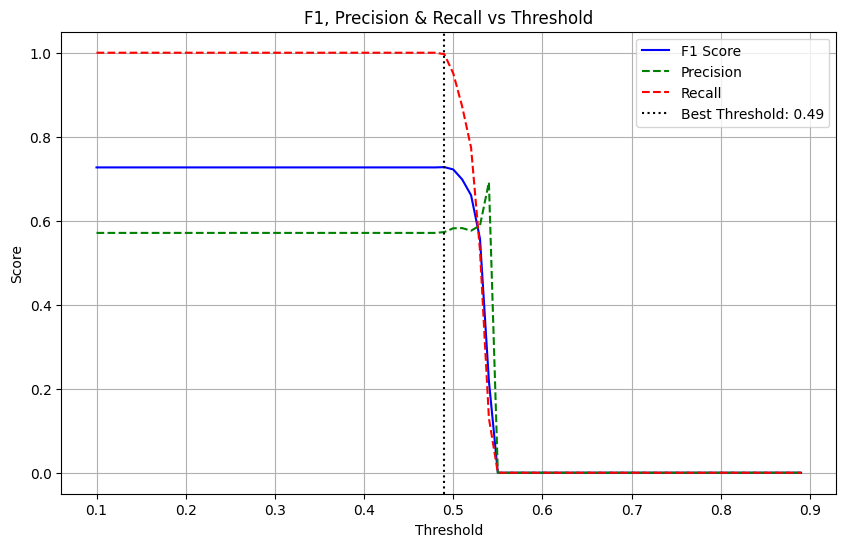

In [19]:
score_df = pd.DataFrame(scores, columns=['Threshold', 'F1', 'Precision', 'Recall'])

plt.figure(figsize=(10, 6))
plt.plot(score_df['Threshold'], score_df['F1'], label='F1 Score', color='blue')
plt.plot(score_df['Threshold'], score_df['Precision'], label='Precision', linestyle='--', color='green')
plt.plot(score_df['Threshold'], score_df['Recall'], label='Recall', linestyle='--', color='red')
plt.axvline(best_thresh, color='black', linestyle=':', label=f'Best Threshold: {best_thresh:.2f}')
plt.title("F1, Precision & Recall vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

## heatmap...

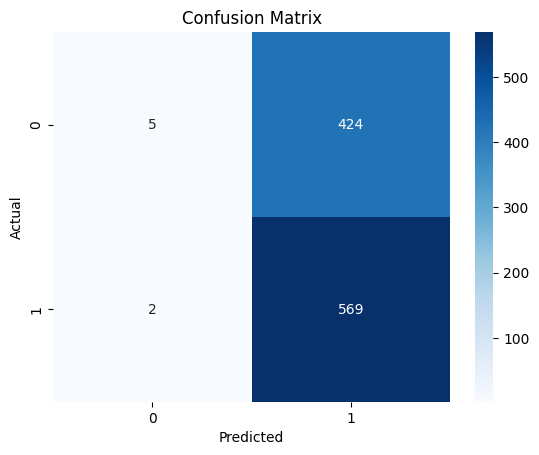

In [20]:
cm = confusion_matrix(y_test, y_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## saving my model

In [ ]:
# model.save("machine_failure_model_final.h5")

## training XGBoost...

In [21]:
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # imbalance adjustment
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:50:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## predicting on test set...

In [22]:
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

## adjusting threshold using 0.49

In [23]:
xgb_pred = (xgb_probs >= 0.49).astype(int)

## Evaluation...

In [24]:
print("🔍 XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, digits=4, zero_division=0))

print("PR AUC:", average_precision_score(y_test, xgb_probs))

🔍 XGBoost Confusion Matrix:
[[251 178]
 [218 353]]

Classification Report:
              precision    recall  f1-score   support

           0     0.5352    0.5851    0.5590       429
           1     0.6648    0.6182    0.6407       571

    accuracy                         0.6040      1000
   macro avg     0.6000    0.6016    0.5998      1000
weighted avg     0.6092    0.6040    0.6056      1000

PR AUC: 0.7126093654102819


## Neural Network...

In [25]:
nn_pred = (y_probs >= 0.49).astype(int)
nn_report = classification_report(y_test, nn_pred, output_dict=True, zero_division=0)
nn_pr_auc = average_precision_score(y_test, y_probs)
nn_acc = accuracy_score(y_test, nn_pred)

## XGBoost...

In [26]:
xgb_pred = (xgb_probs >= 0.49).astype(int)
xgb_report = classification_report(y_test, xgb_pred, output_dict=True, zero_division=0)
xgb_pr_auc = average_precision_score(y_test, xgb_probs)
xgb_acc = accuracy_score(y_test, xgb_pred)

## dataframe for comparison...

In [27]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Class 0 Precision', 'Class 0 Recall', 'Class 0 F1',
               'Class 1 Precision', 'Class 1 Recall', 'Class 1 F1', 'PR AUC'],
    'Neural Network': [
        nn_acc,
        nn_report['0']['precision'],
        nn_report['0']['recall'],
        nn_report['0']['f1-score'],
        nn_report['1']['precision'],
        nn_report['1']['recall'],
        nn_report['1']['f1-score'],
        nn_pr_auc
    ],
    'XGBoost': [
        xgb_acc,
        xgb_report['0']['precision'],
        xgb_report['0']['recall'],
        xgb_report['0']['f1-score'],
        xgb_report['1']['precision'],
        xgb_report['1']['recall'],
        xgb_report['1']['f1-score'],
        xgb_pr_auc
    ]
})

comparison_df.set_index('Metric', inplace=True)
comparison_df = comparison_df.round(4)
comparison_df

,Neural Network,XGBoost
Metric,,
Accuracy,0.5740,0.6040
Class 0 Precision,0.7143,0.5352
Class 0 Recall,0.0117,0.5851
Class 0 F1,0.0229,0.5590
Class 1 Precision,0.5730,0.6648
Class 1 Recall,0.9965,0.6182
Class 1 F1,0.7276,0.6407
PR AUC,0.6039,0.7126


## bar chart visualization...

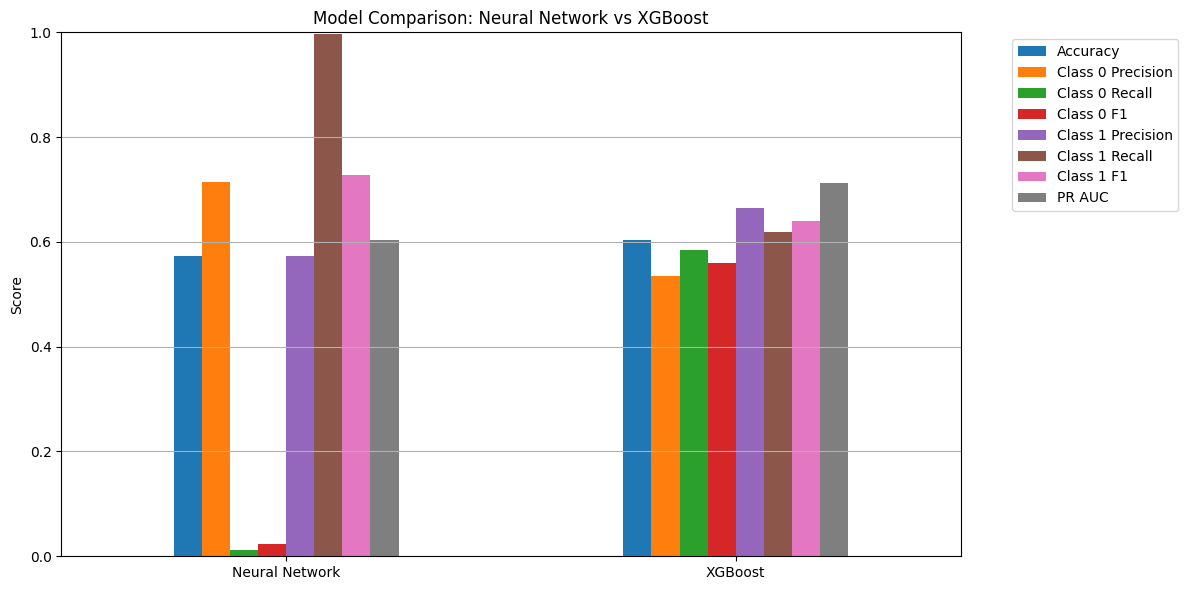

In [28]:
comparison_df.T.plot(kind='bar', figsize=(12, 6))
plt.title("Model Comparison: Neural Network vs XGBoost")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## confusion matrix...

In [29]:
# Neural Network
nn_cm = confusion_matrix(y_test, nn_pred)

# XGBoost
xgb_cm = confusion_matrix(y_test, xgb_pred)

## confusion matrix visualization...

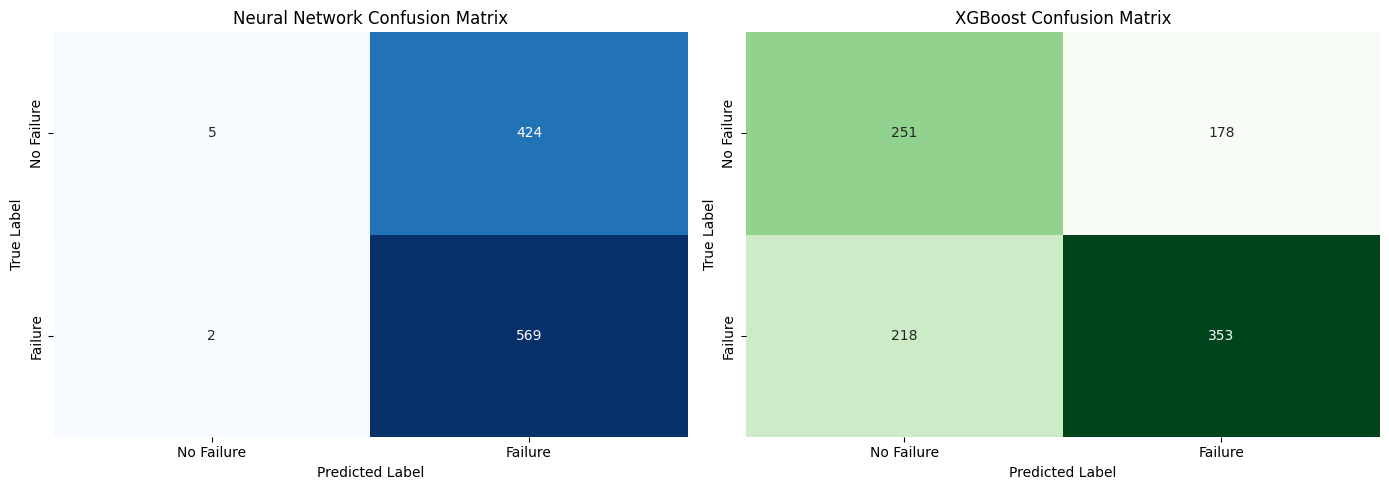

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Neural Network CM
sns.heatmap(nn_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title("Neural Network Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
axes[0].set_xticklabels(['No Failure', 'Failure'])
axes[0].set_yticklabels(['No Failure', 'Failure'])

# XGBoost CM
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title("XGBoost Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")
axes[1].set_xticklabels(['No Failure', 'Failure'])
axes[1].set_yticklabels(['No Failure', 'Failure'])

plt.tight_layout()
plt.show()

## stratified k-fold cross validation...

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='f1')
print("Mean F1 Score:", scores.mean())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:51:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:51:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:51:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mean F1 Score: 0.6299538705498671


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:51:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:51:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## --- Additional Baseline Model Evaluations ---

In [32]:
# 1. Logistic Regression...
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]
print("Logistic Regression:")
print(confusion_matrix(y_test, lr_preds))
print(classification_report(y_test, lr_preds, digits=4))
print("PR AUC:", average_precision_score(y_test, lr_probs))

# 2. Random Forest...
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
print("Random Forest:")
print(confusion_matrix(y_test, rf_preds))
print(classification_report(y_test, rf_preds, digits=4))
print("PR AUC:", average_precision_score(y_test, rf_probs))

# 3. Support Vector Machine...
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)
svm_probs = svm_model.predict_proba(X_test)[:, 1]
print("Support Vector Machine:")
print(confusion_matrix(y_test, svm_preds))
print(classification_report(y_test, svm_preds, digits=4))
print("PR AUC:", average_precision_score(y_test, svm_probs))

Logistic Regression:
[[  0 429]
 [  0 571]]
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       429
           1     0.5710    1.0000    0.7269       571

    accuracy                         0.5710      1000
   macro avg     0.2855    0.5000    0.3635      1000
weighted avg     0.3260    0.5710    0.4151      1000

PR AUC: 0.5607030263487378


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest:
[[220 209]
 [210 361]]
              precision    recall  f1-score   support

           0     0.5116    0.5128    0.5122       429
           1     0.6333    0.6322    0.6328       571

    accuracy                         0.5810      1000
   macro avg     0.5725    0.5725    0.5725      1000
weighted avg     0.5811    0.5810    0.5811      1000

PR AUC: 0.6645114249594871
Support Vector Machine:
[[ 39 390]
 [ 32 539]]
              precision    recall  f1-score   support

           0     0.5493    0.0909    0.1560       429
           1     0.5802    0.9440    0.7187       571

    accuracy                         0.5780      1000
   macro avg     0.5647    0.5174    0.4373      1000
weighted avg     0.5669    0.5780    0.4773      1000

PR AUC: 0.6274755840972166


## Hyperparameter tuning using GridSearchCV...

In [33]:
params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'scale_pos_weight': [5, 10]
}

grid = GridSearchCV(estimator=xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
                    param_grid=params,
                    scoring='f1',
                    cv=3,
                    n_jobs=-1)
grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)

Best Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'scale_pos_weight': 5}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:52:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## LIME for Explainability...

In [34]:
def predict_fn(x):
    probs = model.predict(x)  # shape: (n_samples, 1), prob of class 1
    return np.hstack([1 - probs, probs])  # shape: (n_samples, 2)

In [35]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=X.columns,
    class_names=['No Failure', 'Failure'],
    mode='classification'
)

i = 5  # Index of test sample
exp = explainer.explain_instance(X_test[i], predict_fn)
exp.show_in_notebook()

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


## SHAP Interpretation...

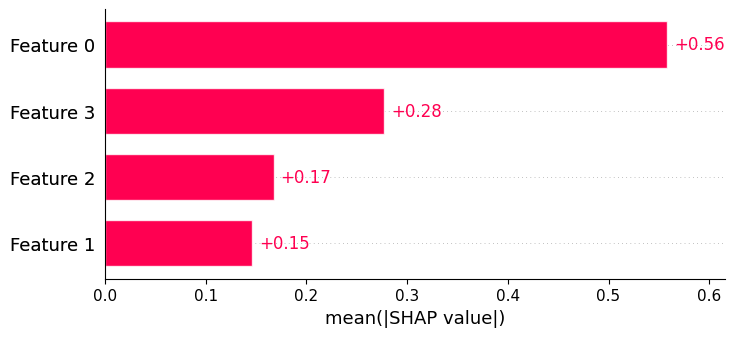

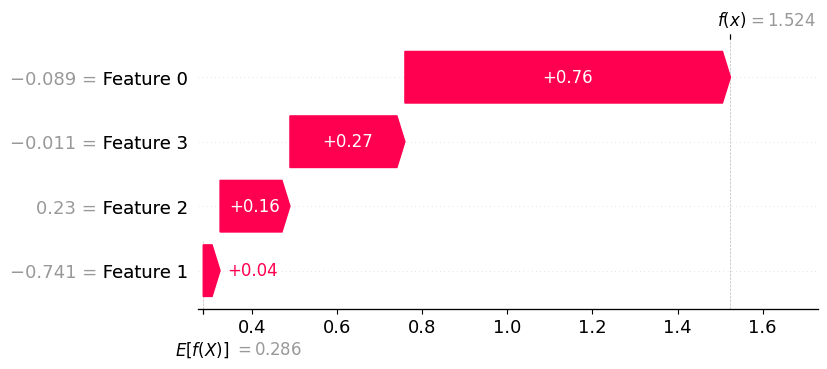

In [36]:
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

# Global Feature Importance
shap.plots.bar(shap_values)

# Individual Prediction Explanation
shap.plots.waterfall(shap_values[5])

## prediction of last sample test....

In [37]:
# Get the last 20 positions (0-based) from y_test
positions = list(range(len(y_test)))[-20:]  # This gives [980, 981, ..., 999]

# Get the corresponding original DataFrame index for reference
sample_indices = y_test.index[-20:]  # These are the original indices like 4980–4999

# Now safely build the final DataFrame
final_preds = pd.DataFrame({
    'Index': sample_indices,  # original index
    'Actual': y_test.iloc[positions].values,  # actual labels
    'Predicted_Label': y_final[positions],    # predicted classes
    'Predicted_Probability': y_probs[positions]  # predicted probabilities
})

print(final_preds)

    Index  Actual  Predicted_Label  Predicted_Probability
0    4921       1                1               0.527597
1    2860       0                0               0.482179
2    3516       1                1               0.495041
3      19       0                1               0.495461
4    2655       1                1               0.526831
5    1494       1                1               0.540551
6    1638       0                1               0.533907
7    3934       1                1               0.530646
8    2111       0                1               0.530956
9    3053       1                1               0.507304
10   4459       1                1               0.507776
11   4573       0                1               0.545856
12   2144       1                1               0.523227
13    311       1                1               0.537869
14   2721       1                1               0.540510
15   2904       1                1               0.534537
16    699     

## prediction visualization...

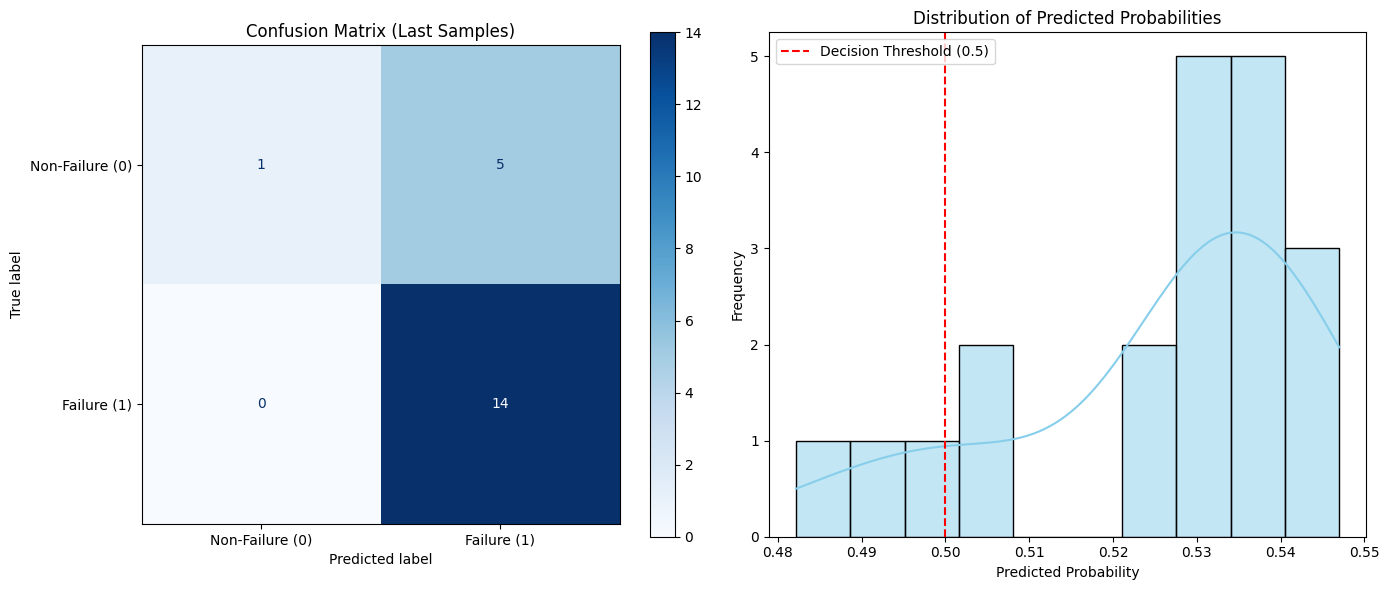

In [38]:
# Creating confusion matrix...
cm = confusion_matrix(final_preds['Actual'], final_preds['Predicted_Label'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Failure (0)", "Failure (1)"])

# Plotting....
plt.figure(figsize=(14, 6))

# Confusion Matrix Plot...
plt.subplot(1, 2, 1)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("Confusion Matrix (Last Samples)")

# Probability Histogram Plot...
plt.subplot(1, 2, 2)
sns.histplot(final_preds['Predicted_Probability'], bins=10, kde=True, color='skyblue', edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()